In [ ]:
import math, time, copy, os
from dataclasses import dataclass
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [ ]:
@dataclass
class Config:
    # grid / time
    nx_hr: int = 64
    ny_hr: int = 64
    nt_hr: int = 14
    s_up: int = 4
    t_up: int = 2

    # physical parameters from the model
    mu_w: float = 1.0
    mu_n: float = 4.0
    Swc: float = 0.20          # S_*
    Smax: float = 0.90         # S^*
    n_w: float = 3.0
    n_n: float = 2.0

    Pinj: float = 1.00         # P^zb_{и}
    Pprod: float = 0.22        # P^zb_{д}
    Pgamma: float = 0.22       # P_Γ
    S_plus: float = 0.23       # S^(+) on Γ(+)

    H0: float = 1.0
    m0: float = 0.24

    # synthetic HR solver
    dt: float = 0.0025
    sat_substeps: int = 3
    n_pressure_iters: int = 260
    well_radius: int = 2
    n_cases: int = 20
    cfl: float = 0.45
    epsilon_sat: float = 1e-4
    epsilon_front: float = 0.05
    well_radius_phys: float = 0.02

    # training
    batch_size: int = 1
    lr: float = 1.5e-3
    weight_decay: float = 1e-6
    epochs: int = 55
    physics_start_epoch: int = 28
    physics_ramp_epochs: int = 14
    max_phys_w: float = 2e-4
    alpha_p: float = 0.06
    alpha_s: float = 0.08
    early_stopping_patience: int = 10
    early_stopping_min_delta: float = 5e-5
    lr_scheduler_factor: float = 0.5
    lr_scheduler_patience: int = 3
    lr_scheduler_min: float = 1e-5
    finetune_lr: float = 7e-5
    freeze_backbone_on_physics: bool = True

    # losses
    front_theta: float = 0.55
    front_k: float = 28.0
    loss_p_l1: float = 1.0
    loss_p_grad: float = 0.12
    loss_s_l1: float = 1.0
    loss_s_grad: float = 0.22
    loss_s_front: float = 0.35
    loss_residual_reg: float = 0.01
    loss_identity: float = 0.01

    # target thresholds, percent
    target_ff_P: float = 5.0
    target_ff_S: float = 8.0
    target_ff_joint: float = 7.0

cfg = Config()
cfg.nx_lr = cfg.nx_hr // cfg.s_up
cfg.ny_lr = cfg.ny_hr // cfg.s_up
cfg.nt_lr = math.ceil(cfg.nt_hr / cfg.t_up)
cfg.dx = 1.0 / (cfg.nx_hr - 1)
cfg.dy = 1.0 / (cfg.ny_hr - 1)

print(cfg)



Config(nx_hr=64, ny_hr=64, nt_hr=14, s_up=4, t_up=2, mu_w=1.0, mu_n=4.0, Swc=0.2, Smax=0.9, n_w=3.0, n_n=2.0, Pinj=1.0, Pprod=0.22, Pgamma=0.22, S_plus=0.23, H0=1.0, m0=0.24, dt=0.0025, sat_substeps=3, n_pressure_iters=260, well_radius=2, n_cases=20, cfl=0.45, epsilon_sat=0.0001, epsilon_front=0.05, well_radius_phys=0.02, batch_size=1, lr=0.0015, weight_decay=1e-06, epochs=55, physics_start_epoch=28, physics_ramp_epochs=14, max_phys_w=0.0002, alpha_p=0.06, alpha_s=0.08, early_stopping_patience=10, early_stopping_min_delta=5e-05, lr_scheduler_factor=0.5, lr_scheduler_patience=3, lr_scheduler_min=1e-05, finetune_lr=7e-05, freeze_backbone_on_physics=True, front_theta=0.55, front_k=28.0, loss_p_l1=1.0, loss_p_grad=0.12, loss_s_l1=1.0, loss_s_grad=0.22, loss_s_front=0.35, loss_residual_reg=0.01, loss_identity=0.01, target_ff_P=5.0, target_ff_S=8.0, target_ff_joint=7.0)


## 2. Генератор HR-решения, согласованный с (1.2.1)–(1.2.11)


In [ ]:
def smooth_noise(ny, nx, seed, sweeps=22):
    rng = np.random.default_rng(seed)
    z = rng.normal(size=(ny, nx))
    for _ in range(sweeps):
        z = (
            4.0 * z +
            np.roll(z, 1, 0) + np.roll(z, -1, 0) +
            np.roll(z, 1, 1) + np.roll(z, -1, 1)
        ) / 8.0
    z = (z - z.mean()) / (z.std() + 1e-8)
    return z


def circle_mask(ny, nx, cx, cy, radius):
    yy, xx = np.mgrid[0:ny, 0:nx]
    return (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2


def relperm_np(S, cfg):
    Se = np.clip((S - cfg.Swc) / (cfg.Smax - cfg.Swc), 0.0, 1.0)
    Kw = np.where(S <= cfg.Swc, 0.0, Se ** cfg.n_w)
    Kn = np.where(S >= cfg.Smax, 0.0, (1.0 - Se) ** cfg.n_n)
    return Kw.astype(np.float32), Kn.astype(np.float32)


def fw_from_s_np(S, cfg):
    Kw, Kn = relperm_np(S, cfg)
    lam_w = Kw / cfg.mu_w
    lam_n = Kn / cfg.mu_n
    lam_t = lam_w + lam_n + 1e-10
    return (lam_w / lam_t).astype(np.float32)


def make_coefficients(seed, cfg):
    x = np.linspace(0.0, 1.0, cfg.nx_hr)
    y = np.linspace(0.0, 1.0, cfg.ny_hr)
    X, Y = np.meshgrid(x, y)

    Kf = smooth_noise(cfg.ny_hr, cfg.nx_hr, seed=100 + seed, sweeps=24)
    Hf = smooth_noise(cfg.ny_hr, cfg.nx_hr, seed=200 + seed, sweeps=16)
    mf = smooth_noise(cfg.ny_hr, cfg.nx_hr, seed=300 + seed, sweeps=16)

    K = np.exp(0.45 * Kf)
    K /= K.mean()

    H = cfg.H0 * (1.0 + 0.12 * Hf)
    H = np.clip(H, 0.75, 1.25)

    m = cfg.m0 * (1.0 + 0.08 * mf)
    m = np.clip(m, 0.18, 0.30)

    inj_cx, inj_cy = int(0.18 * cfg.nx_hr), int(0.52 * cfg.ny_hr)
    prod_cx, prod_cy = int(0.82 * cfg.nx_hr), int(0.50 * cfg.ny_hr)

    inj_mask = circle_mask(cfg.ny_hr, cfg.nx_hr, inj_cx, inj_cy, cfg.well_radius)
    prod_mask = circle_mask(cfg.ny_hr, cfg.nx_hr, prod_cx, prod_cy, cfg.well_radius)

    S0 = cfg.Swc + 0.012
    S0 = S0 + 0.11 * np.exp(-((X - 0.18)**2 / 0.022 + (Y - 0.52)**2 / 0.034))
    S0 = S0 + 0.02 * np.exp(-((X - 0.30)**2 / 0.040 + (Y - 0.65)**2 / 0.045))
    S0 = np.clip(S0, cfg.Swc + 1e-4, cfg.Smax - 0.10)
    S0[inj_mask] = cfg.Smax

    return K.astype(np.float32), H.astype(np.float32), m.astype(np.float32), inj_mask, prod_mask, S0.astype(np.float32)


In [ ]:
def solve_pressure(S, K, H, inj_mask, prod_mask, cfg):
    ny, nx = S.shape
    Kw, Kn = relperm_np(np.clip(S, cfg.Swc, cfg.Smax), cfg)
    lam_t = Kw / cfg.mu_w + Kn / cfg.mu_n
    sigma = H * K * lam_t + 1e-10

    fixed = np.zeros((ny, nx), dtype=bool)
    fixed[:, 0] = fixed[:, -1] = True
    fixed[0, :] = fixed[-1, :] = True
    fixed[inj_mask] = True
    fixed[prod_mask] = True

    P = np.full((ny, nx), cfg.Pgamma, dtype=np.float64)
    P[inj_mask] = cfg.Pinj
    P[prod_mask] = cfg.Pprod

    unknowns = [(y, x) for y in range(ny) for x in range(nx) if not fixed[y, x]]
    if not unknowns:
        return P.astype(np.float32), sigma.astype(np.float32), fixed

    index = {yx: i for i, yx in enumerate(unknowns)}
    rows, cols, data = [], [], []
    b = np.zeros(len(unknowns), dtype=np.float64)

    for row, (y, x) in enumerate(unknowns):
        ae = 0.5 * (sigma[y, x] + sigma[y, x + 1])
        aw = 0.5 * (sigma[y, x] + sigma[y, x - 1])
        an = 0.5 * (sigma[y, x] + sigma[y + 1, x])
        ass = 0.5 * (sigma[y, x] + sigma[y - 1, x])

        rows.append(row)
        cols.append(row)
        data.append(ae + aw + an + ass)

        for (yy, xx), coef in [((y, x + 1), ae), ((y, x - 1), aw), ((y + 1, x), an), ((y - 1, x), ass)]:
            if fixed[yy, xx]:
                b[row] += coef * P[yy, xx]
            else:
                rows.append(row)
                cols.append(index[(yy, xx)])
                data.append(-coef)

    A = sp.csr_matrix((data, (rows, cols)), shape=(len(unknowns), len(unknowns)))
    sol = spla.spsolve(A, b)
    for (y, x), val in zip(unknowns, sol):
        P[y, x] = val

    return P.astype(np.float32), sigma.astype(np.float32), fixed


def total_flux_faces_np(P, sigma, cfg):
    ny, nx = P.shape
    qx = np.zeros((ny, nx + 1), dtype=np.float32)
    qy = np.zeros((ny + 1, nx), dtype=np.float32)

    sigma_x = 0.5 * (sigma[:, :-1] + sigma[:, 1:])
    qx[:, 1:nx] = -sigma_x * (P[:, 1:] - P[:, :-1]) / cfg.dx
    qx[:, 0] = -sigma[:, 0] * (P[:, 0] - cfg.Pgamma) / (0.5 * cfg.dx)
    qx[:, nx] = -sigma[:, -1] * (cfg.Pgamma - P[:, -1]) / (0.5 * cfg.dx)

    sigma_y = 0.5 * (sigma[:-1, :] + sigma[1:, :])
    qy[1:ny, :] = -sigma_y * (P[1:, :] - P[:-1, :]) / cfg.dy
    qy[0, :] = -sigma[0, :] * (P[0, :] - cfg.Pgamma) / (0.5 * cfg.dy)
    qy[ny, :] = -sigma[-1, :] * (cfg.Pgamma - P[-1, :]) / (0.5 * cfg.dy)
    return qx, qy


def water_flux_faces_np(S, qx, qy, cfg):
    ny, nx = S.shape
    fw = fw_from_s_np(np.clip(S, cfg.Swc, cfg.Smax), cfg)
    fw_plus = float(fw_from_s_np(np.array([[cfg.S_plus]], dtype=np.float32), cfg)[0, 0])

    Fwx = np.zeros((ny, nx + 1), dtype=np.float32)
    Fwy = np.zeros((ny + 1, nx), dtype=np.float32)

    qx_int = qx[:, 1:nx]
    qy_int = qy[1:ny, :]

    Fwx[:, 1:nx] = np.where(qx_int >= 0.0, fw[:, :-1], fw[:, 1:]) * qx_int
    Fwy[1:ny, :] = np.where(qy_int >= 0.0, fw[:-1, :], fw[1:, :]) * qy_int

    Fwx[:, 0] = np.where(qx[:, 0] > 0.0, fw_plus, fw[:, 0]) * qx[:, 0]
    Fwx[:, nx] = np.where(qx[:, nx] < 0.0, fw_plus, fw[:, -1]) * qx[:, nx]
    Fwy[0, :] = np.where(qy[0, :] > 0.0, fw_plus, fw[0, :]) * qy[0, :]
    Fwy[ny, :] = np.where(qy[ny, :] < 0.0, fw_plus, fw[-1, :]) * qy[ny, :]
    return Fwx, Fwy


def sat_rhs_np(S, P, K, H, m, inj_mask, prod_mask, cfg):
    S_work = np.clip(S, cfg.Swc, cfg.Smax).astype(np.float32)
    S_work[inj_mask] = cfg.Smax

    Kw, Kn = relperm_np(S_work, cfg)
    lam_t = Kw / cfg.mu_w + Kn / cfg.mu_n
    sigma = H * K * lam_t + 1e-10

    qx, qy = total_flux_faces_np(P, sigma, cfg)
    Fwx, Fwy = water_flux_faces_np(S_work, qx, qy, cfg)
    div_w = (Fwx[:, 1:] - Fwx[:, :-1]) / cfg.dx + (Fwy[1:, :] - Fwy[:-1, :]) / cfg.dy

    rhs = -div_w / (m * H + 1e-10)

    rhs[0, :] = 0.0
    rhs[-1, :] = 0.0
    rhs[:, 0] = 0.0
    rhs[:, -1] = 0.0
    rhs[inj_mask] = 0.0
    rhs[prod_mask] = 0.0
    return rhs.astype(np.float32), qx, qy, Fwx, Fwy


def update_saturation(S, P, K, H, m, inj_mask, prod_mask, cfg, return_dt=False):
    Kw, Kn = relperm_np(np.clip(S, cfg.Swc, cfg.Smax), cfg)
    lam_t = Kw / cfg.mu_w + Kn / cfg.mu_n
    sigma = H * K * lam_t + 1e-10

    qx, qy = total_flux_faces_np(P, sigma, cfg)
    vel = max(np.max(np.abs(qx)), np.max(np.abs(qy))) / (np.min(m * H) + 1e-10)
    dt = min(cfg.dt, cfg.cfl * min(cfg.dx, cfg.dy) / (vel + 1e-10))

    rhs, _, _, _, _ = sat_rhs_np(S, P, K, H, m, inj_mask, prod_mask, cfg)
    S_new = np.clip(S + dt * rhs, cfg.Swc, cfg.Smax).astype(np.float32)
    S_new[inj_mask] = cfg.Smax

    if return_dt:
        return S_new, float(dt)
    return S_new


def compute_producer_rates(P, S, K, H, prod_mask, cfg):
    Kw, Kn = relperm_np(np.clip(S, cfg.Swc, cfg.Smax), cfg)
    lam_t = Kw / cfg.mu_w + Kn / cfg.mu_n
    sigma = H * K * lam_t + 1e-10

    qx, qy = total_flux_faces_np(P, sigma, cfg)
    Fwx, Fwy = water_flux_faces_np(np.clip(S, cfg.Swc, cfg.Smax), qx, qy, cfg)

    q_total = 0.0
    q_water = 0.0
    ny, nx = P.shape

    for y, x in np.argwhere(prod_mask):
        if x > 0 and not prod_mask[y, x - 1]:
            q_total += qx[y, x]
            q_water += Fwx[y, x]
        if x < nx - 1 and not prod_mask[y, x + 1]:
            q_total -= qx[y, x + 1]
            q_water -= Fwx[y, x + 1]
        if y > 0 and not prod_mask[y - 1, x]:
            q_total += qy[y, x]
            q_water += Fwy[y, x]
        if y < ny - 1 and not prod_mask[y + 1, x]:
            q_total -= qy[y + 1, x]
            q_water -= Fwy[y + 1, x]

    return float(q_total), float(q_water)


def simulate_case(seed, cfg):
    K, H, m, inj_mask, prod_mask, S = make_coefficients(seed, cfg)

    P_seq, S_seq = [], []
    qc_seq, qw_seq = [], []
    dt_frame_seq = []

    P_sub, S_sub = [], []
    dt_substep_seq = []

    P0, _, _ = solve_pressure(S, K, H, inj_mask, prod_mask, cfg)
    P_sub.append(P0.copy())
    S_sub.append(S.copy())

    for t in range(cfg.nt_hr):
        P, _, _ = solve_pressure(S, K, H, inj_mask, prod_mask, cfg)
        qc, qw = compute_producer_rates(P, S, K, H, prod_mask, cfg)

        P_seq.append(P.copy())
        S_seq.append(S.copy())
        qc_seq.append(qc)
        qw_seq.append(qw)

        if t < cfg.nt_hr - 1:
            dt_sum = 0.0
            for _ in range(cfg.sat_substeps):
                S, dt_used = update_saturation(
                    S, P, K, H, m, inj_mask, prod_mask, cfg, return_dt=True
                )
                P, _, _ = solve_pressure(S, K, H, inj_mask, prod_mask, cfg)

                P_sub.append(P.copy())
                S_sub.append(S.copy())
                dt_substep_seq.append(dt_used)
                dt_sum += dt_used

            dt_frame_seq.append(dt_sum)

    hr = np.stack([np.stack(P_seq, axis=0), np.stack(S_seq, axis=0)], axis=1)
    traj = np.stack([np.stack(P_sub, axis=0), np.stack(S_sub, axis=0)], axis=1)

    qc_arr = np.array(qc_seq, dtype=np.float32)
    qw_arr = np.array(qw_seq, dtype=np.float32)

    meta = {
        "K": K,
        "H": H,
        "m": m,
        "inj": inj_mask,
        "prod": prod_mask,
        "Qc": qc_arr,
        "Qw": qw_arr,
        "dt_frame": np.array(dt_frame_seq, dtype=np.float32),
        "dt_substep": np.array(dt_substep_seq, dtype=np.float32),
        "traj": traj.astype(np.float32),
        "watercut": qw_arr / (qc_arr + 1e-10),
    }
    return hr.astype(np.float32), meta

In [ ]:
def make_lr_from_hr(hr, cfg):
    # temporal decimation + spatial averaging
    t_idx = np.arange(0, cfg.nt_hr, cfg.t_up)
    lr = hr[t_idx]
    nt, ch, ny, nx = lr.shape
    lr = lr.reshape(nt, ch, cfg.ny_lr, cfg.s_up, cfg.nx_lr, cfg.s_up).mean(axis=(3, 5))
    return lr.astype(np.float32)

items = []
for seed in range(cfg.n_cases):
    hr, meta = simulate_case(seed, cfg)
    lr = make_lr_from_hr(hr, cfg)
    items.append((lr, hr, meta))

print("cases:", len(items), "LR shape:", items[0][0].shape, "HR shape:", items[0][1].shape)

cases: 20 LR shape: (7, 2, 16, 16) HR shape: (14, 2, 64, 64)


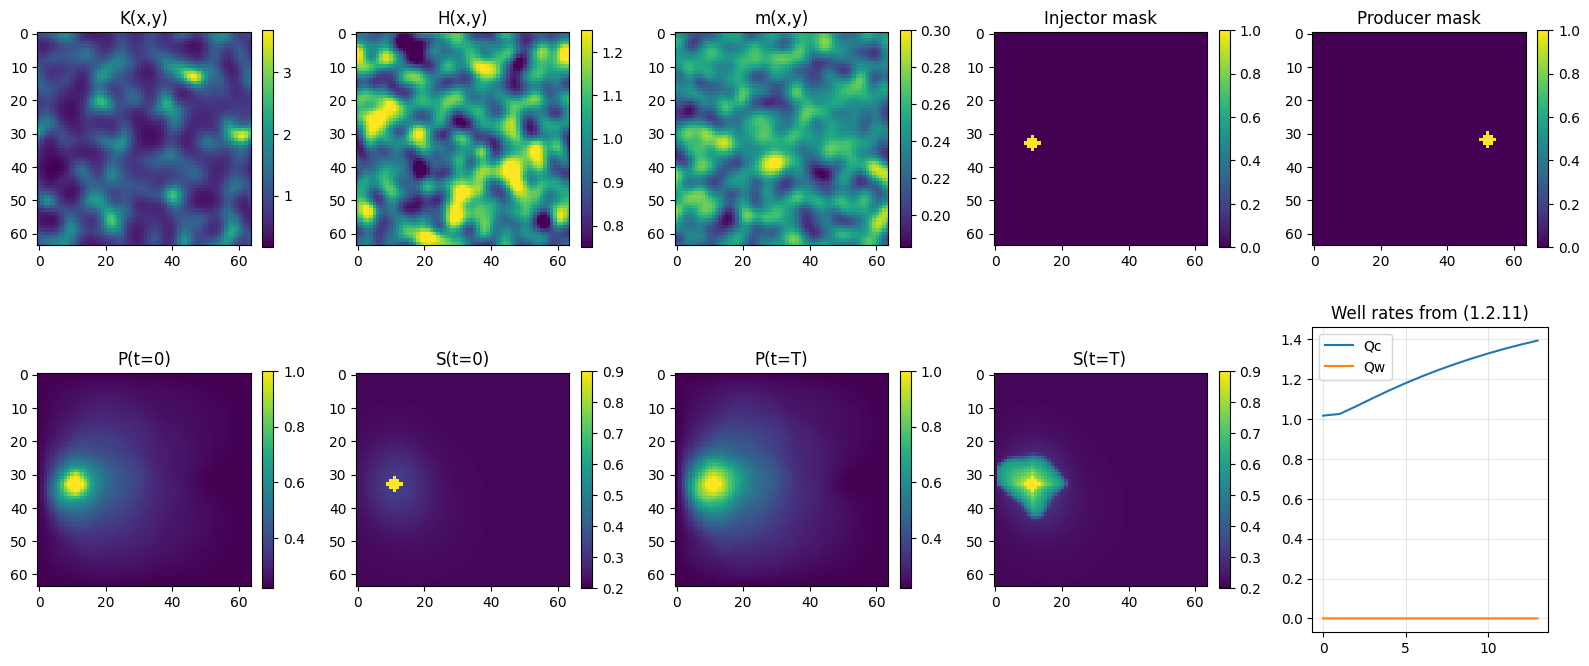

In [ ]:
case_id = 0
lr0, hr0, meta0 = items[case_id]
t0, t1 = 0, cfg.nt_hr - 1

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
ax = axes.ravel()
im0 = ax[0].imshow(meta0["K"]); ax[0].set_title("K(x,y)"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(meta0["H"]); ax[1].set_title("H(x,y)"); plt.colorbar(im1, ax=ax[1], fraction=0.046)
im2 = ax[2].imshow(meta0["m"]); ax[2].set_title("m(x,y)"); plt.colorbar(im2, ax=ax[2], fraction=0.046)
im3 = ax[3].imshow(meta0["inj"]); ax[3].set_title("Injector mask"); plt.colorbar(im3, ax=ax[3], fraction=0.046)
im4 = ax[4].imshow(meta0["prod"]); ax[4].set_title("Producer mask"); plt.colorbar(im4, ax=ax[4], fraction=0.046)
im5 = ax[5].imshow(hr0[t0, 0]); ax[5].set_title("P(t=0)"); plt.colorbar(im5, ax=ax[5], fraction=0.046)
im6 = ax[6].imshow(hr0[t0, 1], vmin=cfg.Swc, vmax=cfg.Smax); ax[6].set_title("S(t=0)"); plt.colorbar(im6, ax=ax[6], fraction=0.046)
im7 = ax[7].imshow(hr0[t1, 0]); ax[7].set_title("P(t=T)"); plt.colorbar(im7, ax=ax[7], fraction=0.046)
im8 = ax[8].imshow(hr0[t1, 1], vmin=cfg.Swc, vmax=cfg.Smax); ax[8].set_title("S(t=T)"); plt.colorbar(im8, ax=ax[8], fraction=0.046)
ax[9].plot(meta0["Qc"], label="Qc")
ax[9].plot(meta0["Qw"], label="Qw")
ax[9].set_title("Well rates from (1.2.11)")
ax[9].grid(True, alpha=0.3)
ax[9].legend()
plt.tight_layout(); plt.show()


## 3. Датасет и нормировка

In [ ]:
class FiltrationDataset(Dataset):
    def __init__(self, items):
        self.items = items

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        lr, hr, meta = self.items[idx]
        return {
            "lr": torch.tensor(lr, dtype=torch.float32),
            "hr": torch.tensor(hr, dtype=torch.float32),
            "K": torch.tensor(meta["K"], dtype=torch.float32),
            "H": torch.tensor(meta["H"], dtype=torch.float32),
            "m": torch.tensor(meta["m"], dtype=torch.float32),
            "inj": torch.tensor(meta["inj"], dtype=torch.bool),
            "prod": torch.tensor(meta["prod"], dtype=torch.bool),
            "Qc": torch.tensor(meta["Qc"], dtype=torch.float32),
            "Qw": torch.tensor(meta["Qw"], dtype=torch.float32),
            "watercut": torch.tensor(meta["watercut"], dtype=torch.float32),
        }

n_train = int(0.75 * len(items))
n_val = max(1, int(0.15 * len(items)))
train_items = items[:n_train]
val_items = items[n_train:n_train+n_val]
test_items = items[n_train+n_val:]

train_ds = FiltrationDataset(train_items)
val_ds = FiltrationDataset(val_items)
test_ds = FiltrationDataset(test_items)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False)

train_hr = np.concatenate([x[1] for x in train_items], axis=0)
mean = torch.tensor(train_hr.mean(axis=(0, 2, 3)), dtype=torch.float32)
std = torch.tensor(train_hr.std(axis=(0, 2, 3)) + 1e-6, dtype=torch.float32)

print("train/val/test:", len(train_items), len(val_items), len(test_items))
print("mean:", mean)
print("std :", std)


train/val/test: 15 3 2
mean: tensor([0.3117, 0.2351])
std : tensor([0.1311, 0.0810])


## 4. ConvLSTM-архитектура PhySR с bounded residual

In [ ]:
class ChannelNorm(nn.Module):
    def __init__(self, mean, std):
        super().__init__()
        self.register_buffer("mean", mean.view(1, 1, 2, 1, 1))
        self.register_buffer("std", std.view(1, 1, 2, 1, 1))

    def encode(self, x):
        return (x - self.mean) / self.std

    def decode(self, x):
        return x * self.std + self.mean

def temporal_interp(x, t_out):
    b, t, c, h, w = x.shape
    z = x.permute(0, 2, 3, 4, 1).reshape(b * c * h * w, 1, t)
    z = F.interpolate(z, size=t_out, mode="linear", align_corners=True)
    z = z.reshape(b, c, h, w, t_out).permute(0, 4, 1, 2, 3)
    return z

def spatial_interp(x, size_hw):
    b, t, c, h, w = x.shape
    z = x.reshape(b * t, c, h, w)
    z = F.interpolate(z, size=size_hw, mode="bicubic", align_corners=True)
    z = z.reshape(b, t, c, size_hw[0], size_hw[1])
    return z

class ResBlock(nn.Module):
    def __init__(self, c):
        super().__init__()
        self.c1 = nn.Conv2d(c, 2*c, 3, padding=1)
        self.c2 = nn.Conv2d(2*c, c, 3, padding=1)

    def forward(self, x):
        return x + 0.1 * self.c2(F.gelu(self.c1(x)))

class ConvLSTMCell(nn.Module):
    def __init__(self, input_dim, hidden_dim, kernel_size=3):
        super().__init__()
        pad = kernel_size // 2
        self.hidden_dim = hidden_dim
        self.gates = nn.Conv2d(input_dim + hidden_dim, 4 * hidden_dim, kernel_size, padding=pad)

    def init_state(self, b, h, w, device, dtype):
        zeros = torch.zeros(b, self.hidden_dim, h, w, device=device, dtype=dtype)
        return zeros, zeros

    def forward(self, x, state):
        h_prev, c_prev = state
        gates = self.gates(torch.cat([x, h_prev], dim=1))
        i, f, g, o = torch.chunk(gates, 4, dim=1)
        i, f, o = torch.sigmoid(i), torch.sigmoid(f), torch.sigmoid(o)
        g = torch.tanh(g)
        c = f * c_prev + i * g
        h = o * torch.tanh(c)
        return h, c

class ResidualPhySRConvLSTM(nn.Module):
    def __init__(self, mean, std, cfg, n_feats=48, n_blocks=4, hidden_dim=48):
        super().__init__()
        self.cfg = cfg
        self.norm = ChannelNorm(mean, std)
        self.head = nn.Conv2d(2, n_feats, 3, padding=1)
        self.body = nn.Sequential(*[ResBlock(n_feats) for _ in range(n_blocks)])
        self.convlstm = ConvLSTMCell(n_feats, hidden_dim)
        self.tail = nn.Sequential(
            nn.Conv2d(hidden_dim, n_feats, 3, padding=1),
            nn.GELU(),
            nn.Conv2d(n_feats, 2, 3, padding=1),
        )

    def forward(self, lr, inj_mask=None, prod_mask=None):
        # lr: [b, t_lr, 2, h_lr, w_lr]
        base = spatial_interp(temporal_interp(lr, self.cfg.nt_hr), (self.cfg.ny_hr, self.cfg.nx_hr))
        z = self.norm.encode(base)

        b, t, c, h, w = z.shape
        state = self.convlstm.init_state(b, h, w, z.device, z.dtype)
        outs = []
        for k in range(t):
            xk = self.head(z[:, k])
            xk = self.body(xk)
            hk, ck = self.convlstm(xk, state)
            state = (hk, ck)
            outs.append(self.tail(hk))
        delta = torch.stack(outs, dim=1)

        base_phys = base
        P = base_phys[:, :, 0:1] + self.cfg.alpha_p * torch.tanh(delta[:, :, 0:1])
        S = base_phys[:, :, 1:2] + self.cfg.alpha_s * torch.tanh(delta[:, :, 1:2])
        S = torch.clamp(S, self.cfg.Swc + 1e-4, self.cfg.Smax)
        pred = torch.cat([P, S], dim=2)
        return pred, base

## 5. Loss и целевые метрики: full-field error в стиле PhySR + front loss для $S$

In [ ]:
def relperm_torch(S, cfg):
    Se = torch.clamp((S - cfg.Swc) / (cfg.Smax - cfg.Swc), 0.0, 1.0)
    Kw = torch.where(S <= cfg.Swc, torch.zeros_like(S), Se ** cfg.n_w)
    Kn = torch.where(S >= cfg.Smax, torch.zeros_like(S), (1.0 - Se) ** cfg.n_n)
    return Kw, Kn


def fw_from_s_torch(S, cfg):
    Kw, Kn = relperm_torch(S, cfg)
    lam_w = Kw / cfg.mu_w
    lam_n = Kn / cfg.mu_n
    lam_t = lam_w + lam_n + 1e-12
    return lam_w / lam_t, lam_t


def grad_xy(z):
    dx = z[..., :, 1:] - z[..., :, :-1]
    dy = z[..., 1:, :] - z[..., :-1, :]
    return dx, dy


def soft_front_mask(S, cfg):
    theta = cfg.Swc + cfg.front_theta * (cfg.Smax - cfg.Swc)
    return torch.sigmoid(cfg.front_k * (S - theta))


def physics_weight(epoch, cfg):
    if epoch < cfg.physics_start_epoch:
        return 0.0
    frac = (epoch - cfg.physics_start_epoch + 1) / max(1, cfg.physics_ramp_epochs)
    frac = min(1.0, max(0.0, frac))
    return cfg.max_phys_w * (frac ** 2)


def enforce_bc_batch(state, inj_mask, prod_mask, cfg):
    P = state[:, :, 0]
    S = state[:, :, 1]

    b, t, ny, nx = P.shape
    boundary2d = torch.zeros((b, ny, nx), dtype=torch.bool, device=state.device)
    boundary2d[:, 0, :] = True
    boundary2d[:, -1, :] = True
    boundary2d[:, :, 0] = True
    boundary2d[:, :, -1] = True

    boundary = boundary2d[:, None, :, :]
    inj = inj_mask[:, None, :, :]
    prod = prod_mask[:, None, :, :]

    P = torch.where(boundary, torch.full_like(P, cfg.Pgamma), P)
    P = torch.where(inj, torch.full_like(P, cfg.Pinj), P)
    P = torch.where(prod, torch.full_like(P, cfg.Pprod), P)

    S = torch.where(inj, torch.full_like(S, cfg.Smax), S)
    S = torch.clamp(S, cfg.Swc + 1e-4, cfg.Smax)

    return torch.stack([P, S], dim=2)


def total_flux_faces_torch(P, sigma, cfg):
    b, t, ny, nx = P.shape

    qx = torch.zeros(b, t, ny, nx + 1, device=P.device, dtype=P.dtype)
    qy = torch.zeros(b, t, ny + 1, nx, device=P.device, dtype=P.dtype)

    sigma_x = 0.5 * (sigma[:, :, :, :-1] + sigma[:, :, :, 1:])
    qx[:, :, :, 1:nx] = -sigma_x * (P[:, :, :, 1:] - P[:, :, :, :-1]) / cfg.dx
    qx[:, :, :, 0] = -sigma[:, :, :, 0] * (P[:, :, :, 0] - cfg.Pgamma) / (0.5 * cfg.dx)
    qx[:, :, :, nx] = -sigma[:, :, :, -1] * (cfg.Pgamma - P[:, :, :, -1]) / (0.5 * cfg.dx)

    sigma_y = 0.5 * (sigma[:, :, :-1, :] + sigma[:, :, 1:, :])
    qy[:, :, 1:ny, :] = -sigma_y * (P[:, :, 1:, :] - P[:, :, :-1, :]) / cfg.dy
    qy[:, :, 0, :] = -sigma[:, :, 0, :] * (P[:, :, 0, :] - cfg.Pgamma) / (0.5 * cfg.dy)
    qy[:, :, ny, :] = -sigma[:, :, -1, :] * (cfg.Pgamma - P[:, :, -1, :]) / (0.5 * cfg.dy)
    return qx, qy


def water_flux_faces_torch(S, qx, qy, cfg):
    b, t, ny, nx = S.shape
    fw, _ = fw_from_s_torch(torch.clamp(S, cfg.Swc, cfg.Smax), cfg)
    fw_plus = float(
        fw_from_s_torch(
            torch.tensor([[[[cfg.S_plus]]]], device=S.device, dtype=S.dtype), cfg
        )[0].item()
    )

    Fwx = torch.zeros(b, t, ny, nx + 1, device=S.device, dtype=S.dtype)
    Fwy = torch.zeros(b, t, ny + 1, nx, device=S.device, dtype=S.dtype)

    qx_int = qx[:, :, :, 1:nx]
    qy_int = qy[:, :, 1:ny, :]

    Fwx[:, :, :, 1:nx] = torch.where(qx_int >= 0, fw[:, :, :, :-1], fw[:, :, :, 1:]) * qx_int
    Fwy[:, :, 1:ny, :] = torch.where(qy_int >= 0, fw[:, :, :-1, :], fw[:, :, 1:, :]) * qy_int

    Fwx[:, :, :, 0] = torch.where(qx[:, :, :, 0] > 0, torch.full_like(qx[:, :, :, 0], fw_plus), fw[:, :, :, 0]) * qx[:, :, :, 0]
    Fwx[:, :, :, nx] = torch.where(qx[:, :, :, nx] < 0, torch.full_like(qx[:, :, :, nx], fw_plus), fw[:, :, :, -1]) * qx[:, :, :, nx]
    Fwy[:, :, 0, :] = torch.where(qy[:, :, 0, :] > 0, torch.full_like(qy[:, :, 0, :], fw_plus), fw[:, :, 0, :]) * qy[:, :, 0, :]
    Fwy[:, :, ny, :] = torch.where(qy[:, :, ny, :] < 0, torch.full_like(qy[:, :, ny, :], fw_plus), fw[:, :, -1, :]) * qy[:, :, ny, :]
    return Fwx, Fwy


def active_mask_torch(inj_mask, prod_mask):
    mask = torch.ones_like(inj_mask, dtype=torch.float32)
    mask[:, 0, :] = 0.0
    mask[:, -1, :] = 0.0
    mask[:, :, 0] = 0.0
    mask[:, :, -1] = 0.0
    mask = mask * (~inj_mask).float() * (~prod_mask).float()
    return mask


def masked_mean_sq(z, mask, eps=1e-12):
    num = (z.pow(2) * mask).sum()
    den = mask.sum() + eps
    return num / den


def physics_terms(pred, K_field, H_field, m_field, inj_mask, prod_mask, cfg, dt_step=None):
    P = pred[:, :, 0]
    S = pred[:, :, 1]

    K = K_field[:, None]
    H = H_field[:, None]
    m = m_field[:, None]

    S = torch.clamp(S, cfg.Swc, cfg.Smax)
    S = torch.where(inj_mask[:, None], torch.full_like(S, cfg.Smax), S)

    _, lam_t = fw_from_s_torch(S, cfg)
    sigma = H * K * lam_t + 1e-10

    qx, qy = total_flux_faces_torch(P, sigma, cfg)
    Fwx, Fwy = water_flux_faces_torch(S, qx, qy, cfg)

    div_total = (qx[:, :, :, 1:] - qx[:, :, :, :-1]) / cfg.dx + (qy[:, :, 1:, :] - qy[:, :, :-1, :]) / cfg.dy
    div_water = (Fwx[:, :, :, 1:] - Fwx[:, :, :, :-1]) / cfg.dx + (Fwy[:, :, 1:, :] - Fwy[:, :, :-1, :]) / cfg.dy

    act2d = active_mask_torch(inj_mask, prod_mask)
    act = act2d[:, None, :, :].expand(-1, P.shape[1], -1, -1)
    p_res = masked_mean_sq(div_total, act)

    if dt_step is None:
        dt_step = torch.full(
            (P.shape[0], P.shape[1] - 1),
            float(cfg.dt * cfg.sat_substeps),
            device=P.device,
            dtype=P.dtype,
        )
    elif dt_step.dim() == 1:
        dt_step = dt_step.unsqueeze(0)

    St = (S[:, 1:] - S[:, :-1]) / dt_step[:, :, None, None]
    sat_res = m * H * St + div_water[:, :-1]
    s_res = masked_mean_sq(sat_res, act[:, :-1])
    return p_res, s_res


def total_loss(pred_raw, base_raw, hr, K_field, H_field, m_field, inj_mask, prod_mask, epoch, cfg):
    pred = enforce_bc_batch(pred_raw, inj_mask, prod_mask, cfg)
    base = enforce_bc_batch(base_raw, inj_mask, prod_mask, cfg)

    P_pred, S_pred = pred[:, :, 0], pred[:, :, 1]
    P_hr, S_hr = hr[:, :, 0], hr[:, :, 1]
    P_base, S_base = base[:, :, 0], base[:, :, 1]

    rec_p = F.l1_loss(P_pred, P_hr)
    rec_s = F.l1_loss(S_pred, S_hr)

    gp_pred_x, gp_pred_y = grad_xy(P_pred)
    gp_hr_x, gp_hr_y = grad_xy(P_hr)
    gs_pred_x, gs_pred_y = grad_xy(S_pred)
    gs_hr_x, gs_hr_y = grad_xy(S_hr)
    grad_p = F.l1_loss(gp_pred_x, gp_hr_x) + F.l1_loss(gp_pred_y, gp_hr_y)
    grad_s = F.l1_loss(gs_pred_x, gs_hr_x) + F.l1_loss(gs_pred_y, gs_hr_y)

    front_pred = soft_front_mask(S_pred, cfg)
    front_hr = soft_front_mask(S_hr, cfg)
    front_loss = F.l1_loss(front_pred, front_hr)

    residual_reg = ((pred - base) ** 2).mean()
    identity_reg = F.l1_loss(P_pred, P_base) + F.l1_loss(S_pred, S_base)

    phys_p, phys_s = physics_terms(pred, K_field, H_field, m_field, inj_mask, prod_mask, cfg)
    phys_w = physics_weight(epoch, cfg)
    phys = phys_w * phys_s

    loss = (
        cfg.loss_p_l1 * rec_p +
        cfg.loss_p_grad * grad_p +
        cfg.loss_s_l1 * rec_s +
        cfg.loss_s_grad * grad_s +
        cfg.loss_s_front * front_loss +
        cfg.loss_residual_reg * residual_reg +
        cfg.loss_identity * identity_reg +
        phys
    )

    return loss, pred, base, {
        "rec_p": float(rec_p.item()),
        "rec_s": float(rec_s.item()),
        "grad_p": float(grad_p.item()),
        "grad_s": float(grad_s.item()),
        "front_s": float(front_loss.item()),
        "residual_reg": float(residual_reg.item()),
        "identity_reg": float(identity_reg.item()),
        "phys": float(phys.item()),
        "phys_p": float(phys_p.item()),
        "phys_s": float(phys_s.item()),
        "phys_w": phys_w,
    }

## 6. Подготовка модели, full-field error и критерий выбора checkpoint

In [ ]:


def full_field_error(pred, target, eps=1e-12):
    num = torch.sqrt(((pred - target) ** 2).mean())
    den = torch.sqrt((target ** 2).mean()) + eps
    return 100.0 * (num / den).item()

def metric_pack(pred, target):
    ff_total = full_field_error(pred, target)
    ff_p = full_field_error(pred[:, :, 0], target[:, :, 0])
    ff_s = full_field_error(pred[:, :, 1], target[:, :, 1])
    return {"ff_total": ff_total, "ff_P": ff_p, "ff_S": ff_s}

def threshold_report(metrics, cfg):
    return {
        "P<5%": metrics["ff_P"] < cfg.target_ff_P,
        "S<8%": metrics["ff_S"] < cfg.target_ff_S,
        "joint<7%": metrics["ff_total"] < cfg.target_ff_joint,
    }

def target_score(metrics):
    return 0.3 * metrics["ff_P"] + 0.4 * metrics["ff_S"] + 0.3 * metrics["ff_total"]

def make_optimizer(model, lr, cfg):
    params = [p for p in model.parameters() if p.requires_grad]
    return torch.optim.AdamW(params, lr=lr, weight_decay=cfg.weight_decay)

def make_scheduler(optimizer, cfg):
    return torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="min",
        factor=cfg.lr_scheduler_factor,
        patience=cfg.lr_scheduler_patience,
        min_lr=cfg.lr_scheduler_min,
    )

def freeze_backbone_for_finetune(model):
    for module in [model.head, model.body, model.convlstm]:
        for p in module.parameters():
            p.requires_grad = False
    for module in [model.tail]:
        for p in module.parameters():
            p.requires_grad = True

model = ResidualPhySRConvLSTM(mean.to(device), std.to(device), cfg).to(device)
optimizer = make_optimizer(model, cfg.lr, cfg)
scheduler = make_scheduler(optimizer, cfg)
print("params [M]:", sum(p.numel() for p in model.parameters()) / 1e6)


params [M]: 0.520994


## 7. Обучение с выбором лучшего checkpoint по целевому full-field score

In [ ]:
@torch.no_grad()
def evaluate(model, loader, epoch, cfg):
    model.eval()
    rows = []
    for batch in loader:
        lr = batch["lr"].to(device)
        hr = batch["hr"].to(device)
        K_t = batch["K"].to(device)
        H_t = batch["H"].to(device)
        m_t = batch["m"].to(device)
        inj_t = batch["inj"].to(device)
        prod_t = batch["prod"].to(device)

        pred_raw, base_raw = model(lr)
        loss, pred, base, terms = total_loss(pred_raw, base_raw, hr, K_t, H_t, m_t, inj_t, prod_t, epoch, cfg)
        pred_m = metric_pack(pred, hr)
        base_m = metric_pack(base, hr)
        score = target_score(pred_m)

        rows.append({
            "loss": float(loss.item()),
            "ff_total": pred_m["ff_total"],
            "ff_P": pred_m["ff_P"],
            "ff_S": pred_m["ff_S"],
            "score": score,
            "base_total": base_m["ff_total"],
            "base_P": base_m["ff_P"],
            "base_S": base_m["ff_S"],
            "front_s": terms["front_s"],
            "phys": terms["phys"],
            "phys_p": terms["phys_p"],
            "phys_s": terms["phys_s"],
            "phys_w": terms["phys_w"],
        })

    keys = rows[0].keys()
    return {k: float(np.mean([r[k] for r in rows])) for k in keys}


def train(model, train_loader, val_loader, cfg):
    global optimizer, scheduler
    hist = {
        "train_loss": [], "val_loss": [],
        "val_ff_total": [], "val_ff_P": [], "val_ff_S": [],
        "val_score": [], "base_ff_total": [], "base_ff_P": [], "base_ff_S": [],
        "lr": [], "phys_w": [], "phys_p": [], "phys_s": [], "front_s": []
    }
    best = {"score": float("inf"), "state": None, "epoch": 0, "stats": None}
    bad_epochs = 0
    finetune_started = False

    for epoch in range(1, cfg.epochs + 1):
        if (not finetune_started) and cfg.freeze_backbone_on_physics and epoch == cfg.physics_start_epoch:
            freeze_backbone_for_finetune(model)
            optimizer = make_optimizer(model, cfg.finetune_lr, cfg)
            scheduler = make_scheduler(optimizer, cfg)
            finetune_started = True

        model.train()
        train_losses = []
        for batch in train_loader:
            lr = batch["lr"].to(device)
            hr = batch["hr"].to(device)
            K_t = batch["K"].to(device)
            H_t = batch["H"].to(device)
            m_t = batch["m"].to(device)
            inj_t = batch["inj"].to(device)
            prod_t = batch["prod"].to(device)

            optimizer.zero_grad(set_to_none=True)
            pred_raw, base_raw = model(lr)
            loss, pred, base, terms = total_loss(pred_raw, base_raw, hr, K_t, H_t, m_t, inj_t, prod_t, epoch, cfg)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_losses.append(float(loss.item()))

        val_stats = evaluate(model, val_loader, epoch, cfg)
        scheduler.step(val_stats["score"])

        hist["train_loss"].append(float(np.mean(train_losses)))
        hist["val_loss"].append(val_stats["loss"])
        hist["val_ff_total"].append(val_stats["ff_total"])
        hist["val_ff_P"].append(val_stats["ff_P"])
        hist["val_ff_S"].append(val_stats["ff_S"])
        hist["val_score"].append(val_stats["score"])
        hist["base_ff_total"].append(val_stats["base_total"])
        hist["base_ff_P"].append(val_stats["base_P"])
        hist["base_ff_S"].append(val_stats["base_S"])
        hist["lr"].append(float(optimizer.param_groups[0]["lr"]))
        hist["phys_w"].append(val_stats["phys_w"])
        hist["phys_p"].append(val_stats["phys_p"])
        hist["phys_s"].append(val_stats["phys_s"])
        hist["front_s"].append(val_stats["front_s"])

        improved = val_stats["score"] < (best["score"] - cfg.early_stopping_min_delta)
        if improved:
            best = {
                "score": val_stats["score"],
                "state": copy.deepcopy(model.state_dict()),
                "epoch": epoch,
                "stats": copy.deepcopy(val_stats),
            }
            bad_epochs = 0
        else:
            bad_epochs += 1

        if epoch == 1 or epoch % 2 == 0 or improved:
            print(
                f"epoch {epoch:03d} | train={hist['train_loss'][-1]:.4e} | "
                f"val={val_stats['loss']:.4e} | ff={val_stats['ff_total']:.3f}% "
                f"(P={val_stats['ff_P']:.3f}%, S={val_stats['ff_S']:.3f}%) | "
                f"base={val_stats['base_total']:.3f}% | phys_w={val_stats['phys_w']:.3e} | "
                f"lr={optimizer.param_groups[0]['lr']:.2e}"
            )

        if bad_epochs >= cfg.early_stopping_patience:
            print(f"early stopping at epoch {epoch}")
            break

    model.load_state_dict(best["state"])
    print(f"best epoch by target score: {best['epoch']} with ff={best['stats']['ff_total']:.3f}%")
    return hist, best


In [ ]:
start = time.time()
history, best = train(model, train_loader, val_loader, cfg)
print(f"training time: {time.time() - start:.1f} s")

epoch 001 | train=1.4985e-02 | val=1.1663e-02 | ff=4.066% (P=2.983%, S=5.529%) | base=6.180% | phys_w=0.000e+00 | lr=1.50e-03
epoch 002 | train=1.1611e-02 | val=1.0656e-02 | ff=3.809% (P=2.713%, S=5.250%) | base=6.180% | phys_w=0.000e+00 | lr=1.50e-03
epoch 003 | train=1.0357e-02 | val=9.5910e-03 | ff=3.457% (P=2.539%, S=4.696%) | base=6.180% | phys_w=0.000e+00 | lr=1.50e-03
epoch 004 | train=9.4908e-03 | val=9.0432e-03 | ff=3.300% (P=2.521%, S=4.388%) | base=6.180% | phys_w=0.000e+00 | lr=1.50e-03
epoch 005 | train=8.8710e-03 | val=8.4711e-03 | ff=3.155% (P=2.363%, S=4.246%) | base=6.180% | phys_w=0.000e+00 | lr=1.50e-03
epoch 006 | train=8.4394e-03 | val=8.1211e-03 | ff=3.120% (P=2.336%, S=4.194%) | base=6.180% | phys_w=0.000e+00 | lr=1.50e-03
epoch 007 | train=8.2183e-03 | val=8.0790e-03 | ff=3.057% (P=2.397%, S=3.994%) | base=6.180% | phys_w=0.000e+00 | lr=1.50e-03
epoch 008 | train=7.9169e-03 | val=7.6472e-03 | ff=2.973% (P=2.315%, S=3.901%) | base=6.180% | phys_w=0.000e+00 | lr=1

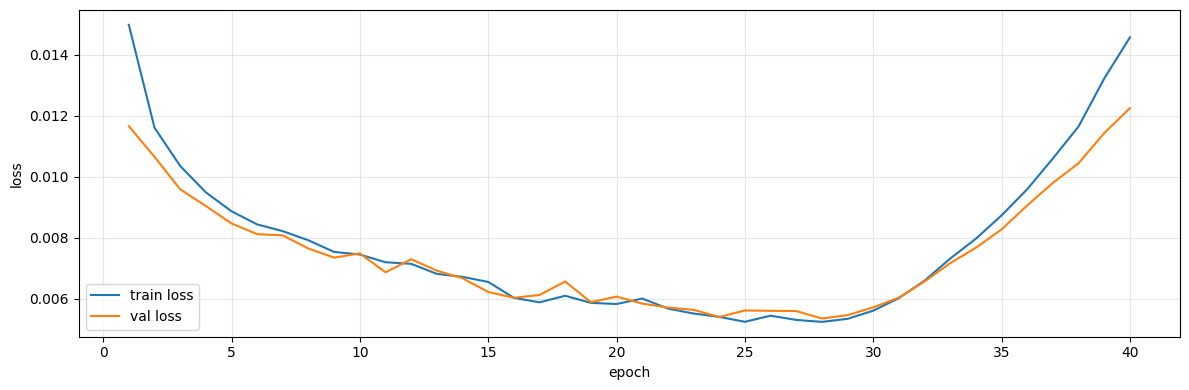

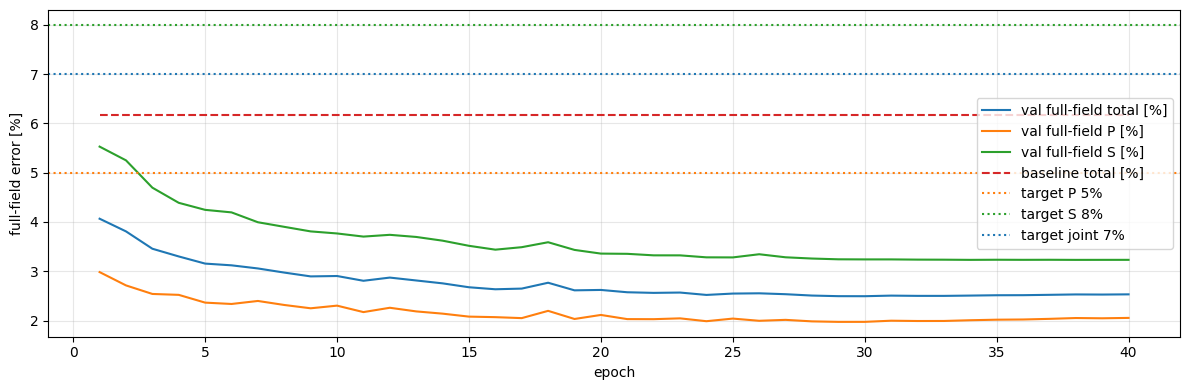

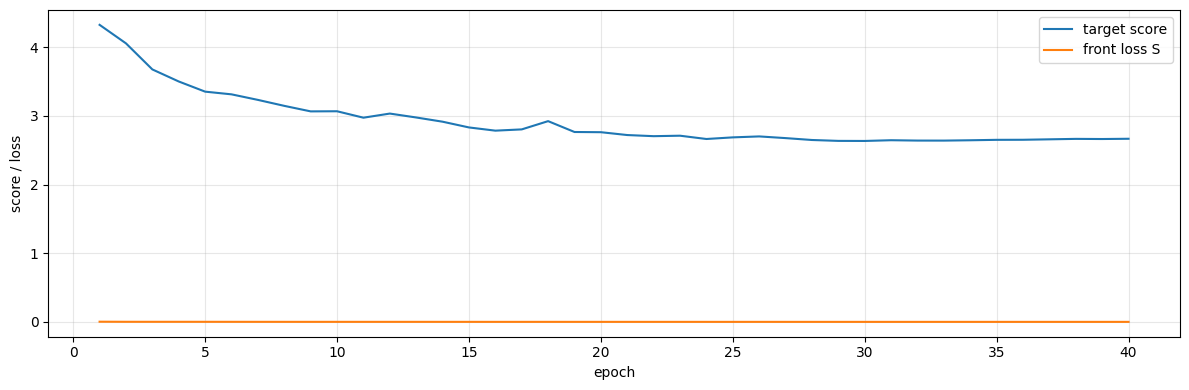

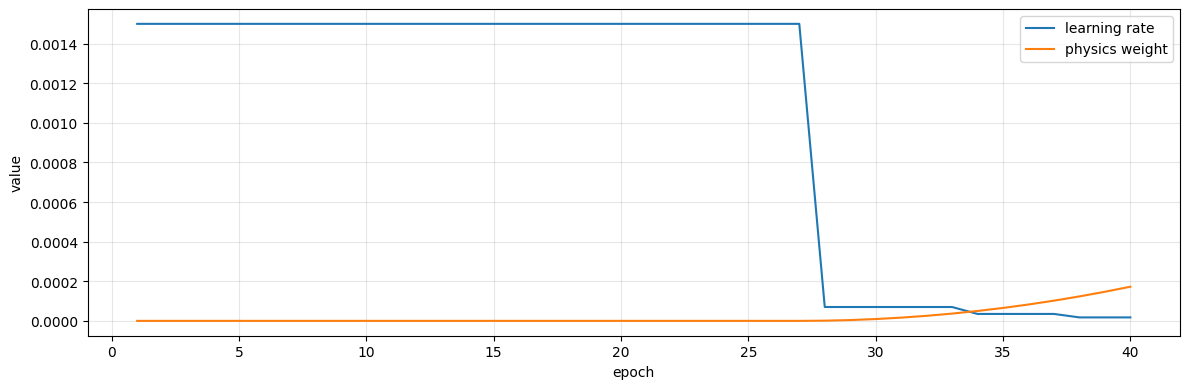

In [ ]:

epochs = np.arange(1, len(history["train_loss"]) + 1)

plt.figure(figsize=(12, 4))
plt.plot(epochs, history["train_loss"], label="train loss")
plt.plot(epochs, history["val_loss"], label="val loss")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 4))
plt.plot(epochs, history["val_ff_total"], label="val full-field total [%]")
plt.plot(epochs, history["val_ff_P"], label="val full-field P [%]")
plt.plot(epochs, history["val_ff_S"], label="val full-field S [%]")
plt.plot(epochs, history["base_ff_total"], "--", label="baseline total [%]")
plt.axhline(cfg.target_ff_P, color="C1", linestyle=":", label="target P 5%")
plt.axhline(cfg.target_ff_S, color="C2", linestyle=":", label="target S 8%")
plt.axhline(cfg.target_ff_joint, color="C0", linestyle=":", label="target joint 7%")
plt.xlabel("epoch"); plt.ylabel("full-field error [%]"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 4))
plt.plot(epochs, history["val_score"], label="target score")
plt.plot(epochs, history["front_s"], label="front loss S")
plt.xlabel("epoch"); plt.ylabel("score / loss"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

plt.figure(figsize=(12, 4))
plt.plot(epochs, history["lr"], label="learning rate")
plt.plot(epochs, history["phys_w"], label="physics weight")
plt.xlabel("epoch"); plt.ylabel("value"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Тест: baseline / SR / HR / error и автоматическая проверка целевых порогов

In [ ]:
model.eval()
batch = test_ds[0]
with torch.no_grad():
    lr_test = batch["lr"].unsqueeze(0).to(device)
    hr_test = batch["hr"].unsqueeze(0).to(device)
    inj_test = batch["inj"].unsqueeze(0).to(device)
    prod_test = batch["prod"].unsqueeze(0).to(device)
    sr_raw, base_raw = model(lr_test)
    sr_test = enforce_bc_batch(sr_raw, inj_test, prod_test, cfg)
    base_test = enforce_bc_batch(base_raw, inj_test, prod_test, cfg)

hr_np = hr_test[0].cpu().numpy()
sr_np = sr_test[0].cpu().numpy()
base_np = base_test[0].cpu().numpy()

base_metrics = metric_pack(base_test, hr_test)
sr_metrics = metric_pack(sr_test, hr_test)
base_checks = threshold_report(base_metrics, cfg)
sr_checks = threshold_report(sr_metrics, cfg)

print("baseline full-field metrics [%]:", base_metrics)
print("SR full-field metrics [%]:", sr_metrics)
print("SR gain total [% points]:", base_metrics["ff_total"] - sr_metrics["ff_total"])
print("threshold checks (baseline):", base_checks)
print("threshold checks (SR):", sr_checks)


baseline full-field metrics [%]: {'ff_total': 6.360217928886414, 'ff_P': 5.603618547320366, 'ff_S': 7.643234729766846}
SR full-field metrics [%]: {'ff_total': 2.513483911752701, 'ff_P': 1.8221139907836914, 'ff_S': 3.5024628043174744}
SR gain total [% points]: 3.8467340171337128
threshold checks (baseline): {'P<5%': False, 'S<8%': True, 'joint<7%': True}
threshold checks (SR): {'P<5%': True, 'S<8%': True, 'joint<7%': True}


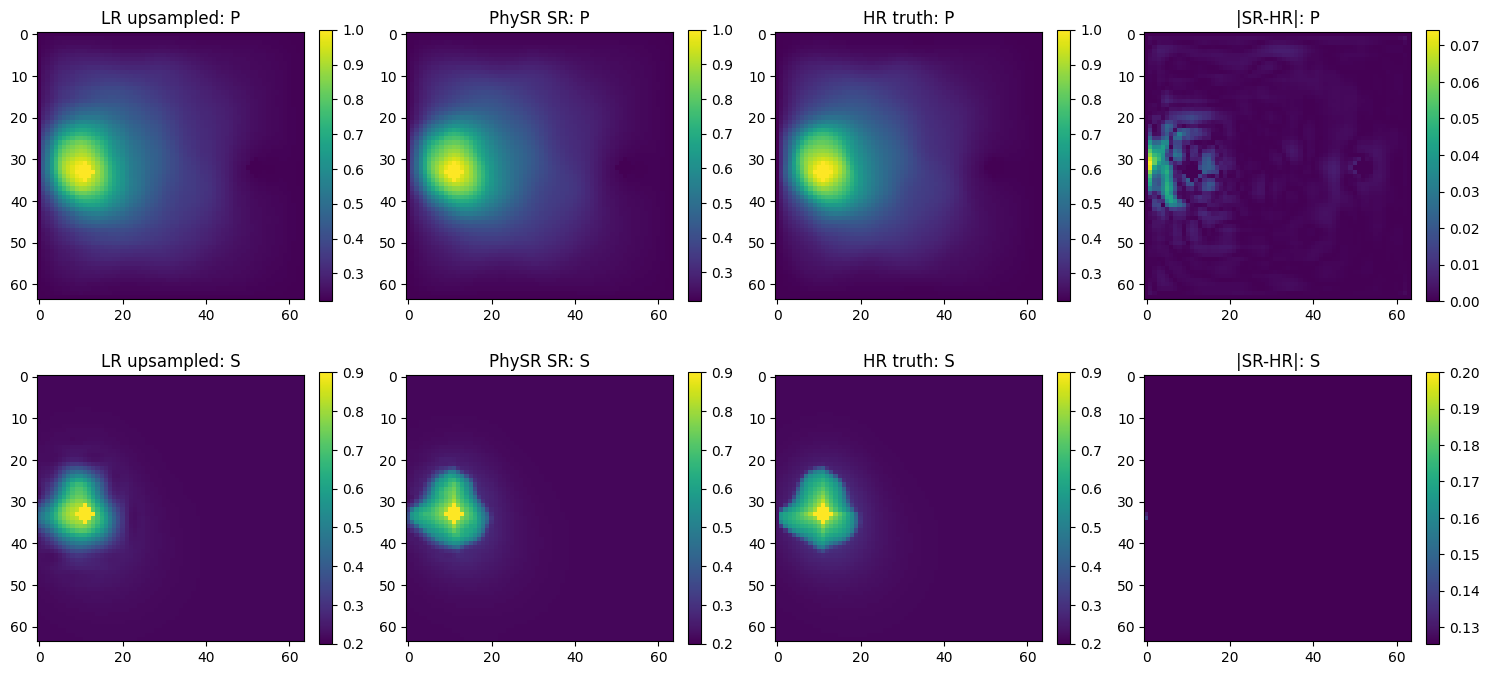

In [ ]:

mid_t = cfg.nt_hr - 1
fig, axes = plt.subplots(2, 4, figsize=(15, 7))

# P
titles = ["LR upsampled: P", "PhySR SR: P", "HR truth: P", "|SR-HR|: P"]
panels = [base_np[mid_t, 0], sr_np[mid_t, 0], hr_np[mid_t, 0], np.abs(sr_np[mid_t, 0] - hr_np[mid_t, 0])]
for j in range(4):
    im = axes[0, j].imshow(panels[j])
    axes[0, j].set_title(titles[j]); plt.colorbar(im, ax=axes[0, j], fraction=0.046)

# S
titles = ["LR upsampled: S", "PhySR SR: S", "HR truth: S", "|SR-HR|: S"]
panels = [base_np[mid_t, 1], sr_np[mid_t, 1], hr_np[mid_t, 1], np.abs(sr_np[mid_t, 1] - hr_np[mid_t, 1])]
for j in range(4):
    im = axes[1, j].imshow(panels[j], vmin=cfg.Swc, vmax=cfg.Smax if j < 3 else None)
    axes[1, j].set_title(titles[j]); plt.colorbar(im, ax=axes[1, j], fraction=0.046)

plt.tight_layout()
plt.show()


P full-field [%]     | baseline= 5.604 | SR= 1.822 | target= 5.00 | pass=True
S full-field [%]     | baseline= 7.643 | SR= 3.502 | target= 8.00 | pass=True
Joint full-field [%] | baseline= 6.360 | SR= 2.513 | target= 7.00 | pass=True


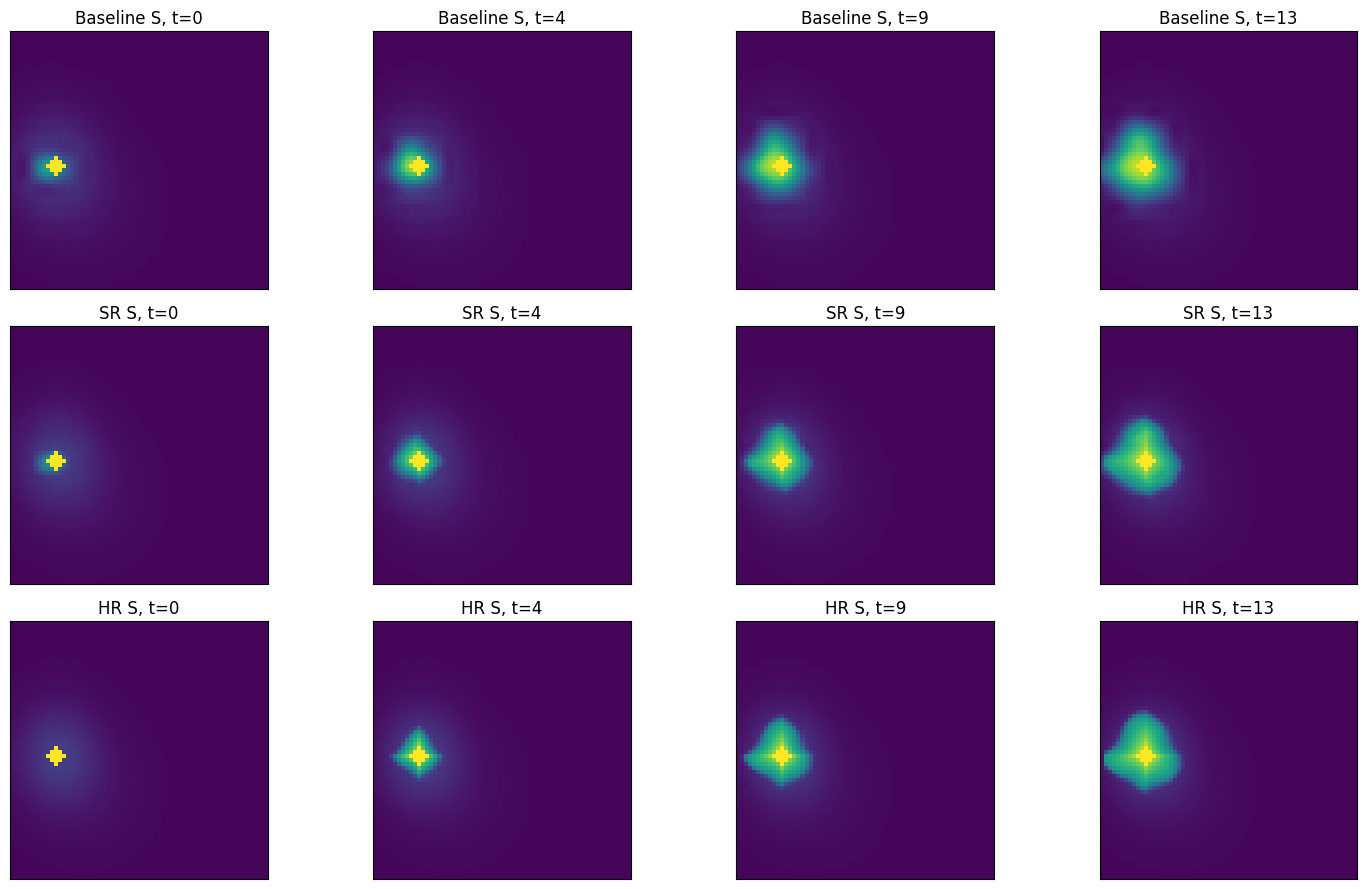

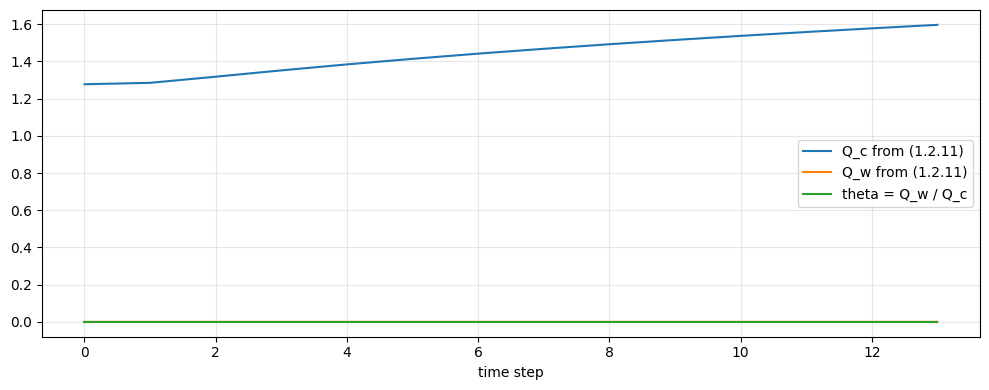

In [ ]:
summary_rows = [
    ["P full-field [%]", base_metrics["ff_P"], sr_metrics["ff_P"], cfg.target_ff_P, sr_checks["P<5%"]],
    ["S full-field [%]", base_metrics["ff_S"], sr_metrics["ff_S"], cfg.target_ff_S, sr_checks["S<8%"]],
    ["Joint full-field [%]", base_metrics["ff_total"], sr_metrics["ff_total"], cfg.target_ff_joint, sr_checks["joint<7%"]],
]
for row in summary_rows:
    print(f"{row[0]:20s} | baseline={row[1]:6.3f} | SR={row[2]:6.3f} | target={row[3]:5.2f} | pass={row[4]}")

times = [0, cfg.nt_hr // 3, 2 * cfg.nt_hr // 3, cfg.nt_hr - 1]
fig, axes = plt.subplots(3, len(times), figsize=(3.8 * len(times), 9))
for j, t in enumerate(times):
    im0 = axes[0, j].imshow(base_np[t, 1], vmin=cfg.Swc, vmax=cfg.Smax)
    axes[0, j].set_title(f"Baseline S, t={t}")
    im1 = axes[1, j].imshow(sr_np[t, 1], vmin=cfg.Swc, vmax=cfg.Smax)
    axes[1, j].set_title(f"SR S, t={t}")
    im2 = axes[2, j].imshow(hr_np[t, 1], vmin=cfg.Swc, vmax=cfg.Smax)
    axes[2, j].set_title(f"HR S, t={t}")
for ax in axes.ravel():
    ax.set_xticks([]); ax.set_yticks([])
plt.tight_layout(); plt.show()

plt.figure(figsize=(10, 4))
plt.plot(batch["Qc"].numpy(), label="Q_c from (1.2.11)")
plt.plot(batch["Qw"].numpy(), label="Q_w from (1.2.11)")
plt.plot(batch["watercut"].numpy(), label="theta = Q_w / Q_c")
plt.xlabel("time step"); plt.grid(True, alpha=0.3); plt.legend(); plt.tight_layout(); plt.show()


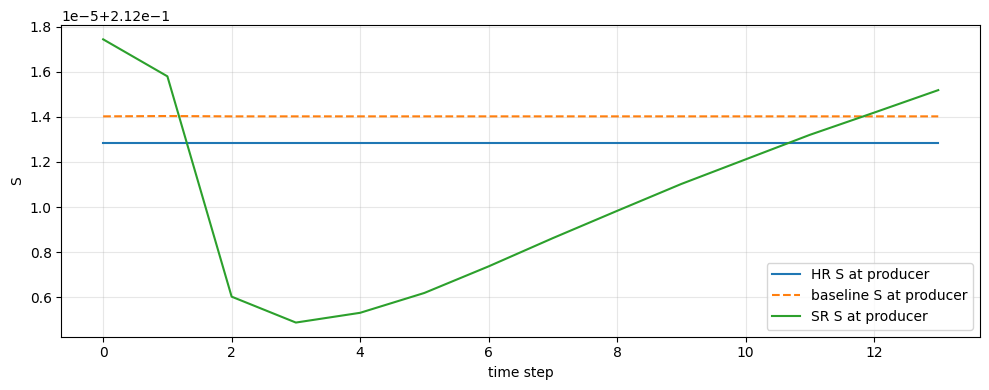

In [ ]:
prod_idx = np.argwhere(batch["prod"].cpu().numpy())
py, px = prod_idx.mean(axis=0).astype(int)

plt.figure(figsize=(10, 4))
plt.plot(hr_np[:, 1, py, px], label="HR S at producer")
plt.plot(base_np[:, 1, py, px], "--", label="baseline S at producer")
plt.plot(sr_np[:, 1, py, px], label="SR S at producer")
plt.xlabel("time step"); plt.ylabel("S"); plt.legend(); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()